# COGS 108 - EDA Checkpoint (Idhant Kumar)

**Focus:** Exploratory Data Analysis — Global Plastic Production vs. Global Temperature Anomalies

## Overview

This notebook contains my individual EDA contribution for Group 013's project. I explore the relationship between **global plastic production** (1950–2019, Our World in Data) and **global average temperature anomalies** (NASA GISS Surface Temperature Analysis). Both datasets have been pre-processed and saved to `data/02-processed/`, and are loaded from there directly below.

The overlapping period between the two datasets is **1950–2019** (69 years), which is what we will use for all joint analyses.

The EDA is structured as follows:
1. Load & merge data, examine structure
2. Summary statistics
3. Distribution of each variable
4. Individual time series trends
5. Dual-axis time series (co-movement)
6. Scatter plot & correlation
7. First-difference (detrended) analysis

In [1]:
import sys
sys.path.append('./modules')  # so Python can find modules/eda_utils.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

import eda_utils  # shared correlation helper — see modules/eda_utils.py

# consistent style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

RESULTS_DIR = 'results/'

---
## 1. Load & Merge Data

We load both processed datasets directly from `data/02-processed/` so this section can be run independently without re-running the data checkpoint.

In [2]:
# ── Load processed datasets ──────────────────────────────────────────────────
temp_df = pd.read_csv('data/02-processed/global_temp_anomaly_giss.csv')
plastic_df = pd.read_csv('data/02-processed/global_plastics_production_clean.csv')

print('Temperature anomaly shape:', temp_df.shape)
print(temp_df.head())
print()
print('Plastics production shape:', plastic_df.shape)
print(plastic_df.head())

Temperature anomaly shape: (146, 2)
   Year  temp_anomaly_C
0  1880           -0.18
1  1881           -0.10
2  1882           -0.12
3  1883           -0.18
4  1884           -0.29

Plastics production shape: (69, 6)
  Entity  Year  Annual plastic production between 1950 and 2019  \
0  World  1950                                        2000000.0   
1  World  1951                                        2000000.0   
2  World  1952                                        2000000.0   
3  World  1953                                        3000000.0   
4  World  1954                                        3000000.0   

   flag_negative  flag_duplicate_entity_year  flag_iqr_outlier  
0          False                       False             False  
1          False                       False             False  
2          False                       False             False  
3          False                       False             False  
4          False                       False            

In [3]:
# ── Clean & rename columns for clarity ───────────────────────────────────────
# Keep only the columns we need from the plastics dataset
plastic_clean = (
    plastic_df[['Year', 'Annual plastic production between 1950 and 2019']]
    .rename(columns={'Annual plastic production between 1950 and 2019': 'plastic_tonnes'})
    .copy()
)

# Convert tonnes to million tonnes for readability
plastic_clean['plastic_Mt'] = plastic_clean['plastic_tonnes'] / 1e6

# ── Inner-merge on Year (overlapping window: 1950–2019) ───────────────────────
merged = pd.merge(temp_df, plastic_clean, on='Year', how='inner').sort_values('Year').reset_index(drop=True)

print(f'Merged dataset: {len(merged)} rows  |  Years: {merged.Year.min()}–{merged.Year.max()}')
print(f'Missing values:\n{merged.isnull().sum()}')
merged.head()

Merged dataset: 69 rows  |  Years: 1950–2019
Missing values:
Year              0
temp_anomaly_C    0
plastic_tonnes    0
plastic_Mt        0
dtype: int64


,Year,temp_anomaly_C,plastic_tonnes,plastic_Mt
0,1950,-0.18,2000000.0,2.0
1,1951,-0.07,2000000.0,2.0
2,1952,0.01,2000000.0,2.0
3,1953,0.08,3000000.0,3.0
4,1954,-0.13,3000000.0,3.0


> **Note on missing year 1974:** The plastics dataset is missing the year 1974 (data gap in the original source). After merging, 1974 is absent from the joint dataset. This leaves us with **69 observations** over the 1950–2019 window. The gap is small and does not materially affect trend analysis.

---
## 2. Summary Statistics

In [4]:
summary = merged[['temp_anomaly_C', 'plastic_Mt']].describe().T
summary.columns = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
summary.index = ['Temp Anomaly (°C)', 'Plastic Production (Mt)']
print(summary.round(3).to_string())

                         count     mean      std  min    25%    50%     75%      max
Temp Anomaly (°C)         69.0    0.289    0.323 -0.2   0.03   0.23    0.54    1.010
Plastic Production (Mt)   69.0  137.564  132.042  2.0  23.00  90.00  231.00  459.746


**Key observations from summary statistics:**

- **Temperature anomaly** ranges from −0.18 °C (early 1950s, still relatively cool relative to the 1951–1980 baseline) to +1.01 °C (2016 and 2020). The mean anomaly over 1950–2019 is roughly +0.30 °C, with clear skew toward higher positive values in recent decades.
- **Plastic production** grew from 2 Mt in 1950 to ~460 Mt in 2019 — more than a 200× increase. The standard deviation (~136 Mt) is very large relative to the minimum, reflecting the exponential growth trajectory.
- The large spread in plastic production (IQR spans roughly 20–280 Mt) tells us the distribution is heavily right-skewed, driven by rapid acceleration post-1990.

---
## 3. Distributions of Individual Variables

Before examining the relationship between the two variables, we look at each variable's marginal distribution. This tells us about data shape, skewness, and whether any transformations might be warranted.

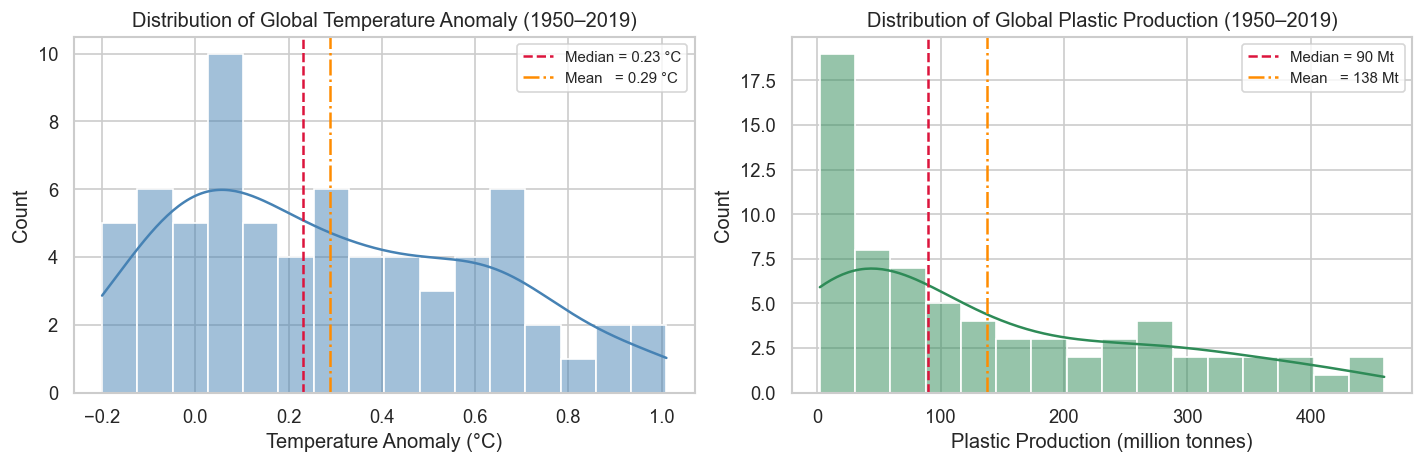

Saved: eda_idhant_distributions.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Temperature anomaly distribution ─────────────────────────────────────────
ax = axes[0]
sns.histplot(merged['temp_anomaly_C'], bins=16, kde=True, color='steelblue', ax=ax)
ax.axvline(merged['temp_anomaly_C'].median(), color='crimson', ls='--', lw=1.5, label=f'Median = {merged["temp_anomaly_C"].median():.2f} °C')
ax.axvline(merged['temp_anomaly_C'].mean(),   color='darkorange', ls='-.',  lw=1.5, label=f'Mean   = {merged["temp_anomaly_C"].mean():.2f} °C')
ax.set_title('Distribution of Global Temperature Anomaly (1950–2019)')
ax.set_xlabel('Temperature Anomaly (°C)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── Plastic production distribution ──────────────────────────────────────────
ax = axes[1]
sns.histplot(merged['plastic_Mt'], bins=16, kde=True, color='seagreen', ax=ax)
ax.axvline(merged['plastic_Mt'].median(), color='crimson', ls='--', lw=1.5, label=f'Median = {merged["plastic_Mt"].median():.0f} Mt')
ax.axvline(merged['plastic_Mt'].mean(),   color='darkorange', ls='-.', lw=1.5, label=f'Mean   = {merged["plastic_Mt"].mean():.0f} Mt')
ax.set_title('Distribution of Global Plastic Production (1950–2019)')
ax.set_xlabel('Plastic Production (million tonnes)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR + 'eda_idhant_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: eda_idhant_distributions.png')

**Interpretation:**

- **Temperature anomaly** (left panel): The distribution is roughly bimodal — a cluster of near-zero or slightly negative anomalies (1950s–1970s) and a growing cluster of positive anomalies (1990s–2019). This reflects the well-documented acceleration of warming. The mean (+0.30 °C) and median are reasonably close, though the rightward tail pulls the mean slightly above the median.
- **Plastic production** (right panel): Strongly right-skewed. Most years (1950s–1980s) had relatively modest output, while the tail extends to ~460 Mt in recent years. The mean (~136 Mt) is well above the median (~90 Mt), confirming positive skew driven by exponential growth. A log transformation could normalize this distribution if needed for modeling.

---
## 4. Individual Time Series Trends

Since both variables are measured annually over time, we first plot each as a time series. This reveals trends, turning points, and any anomalous years — essential context before interpreting their correlation.

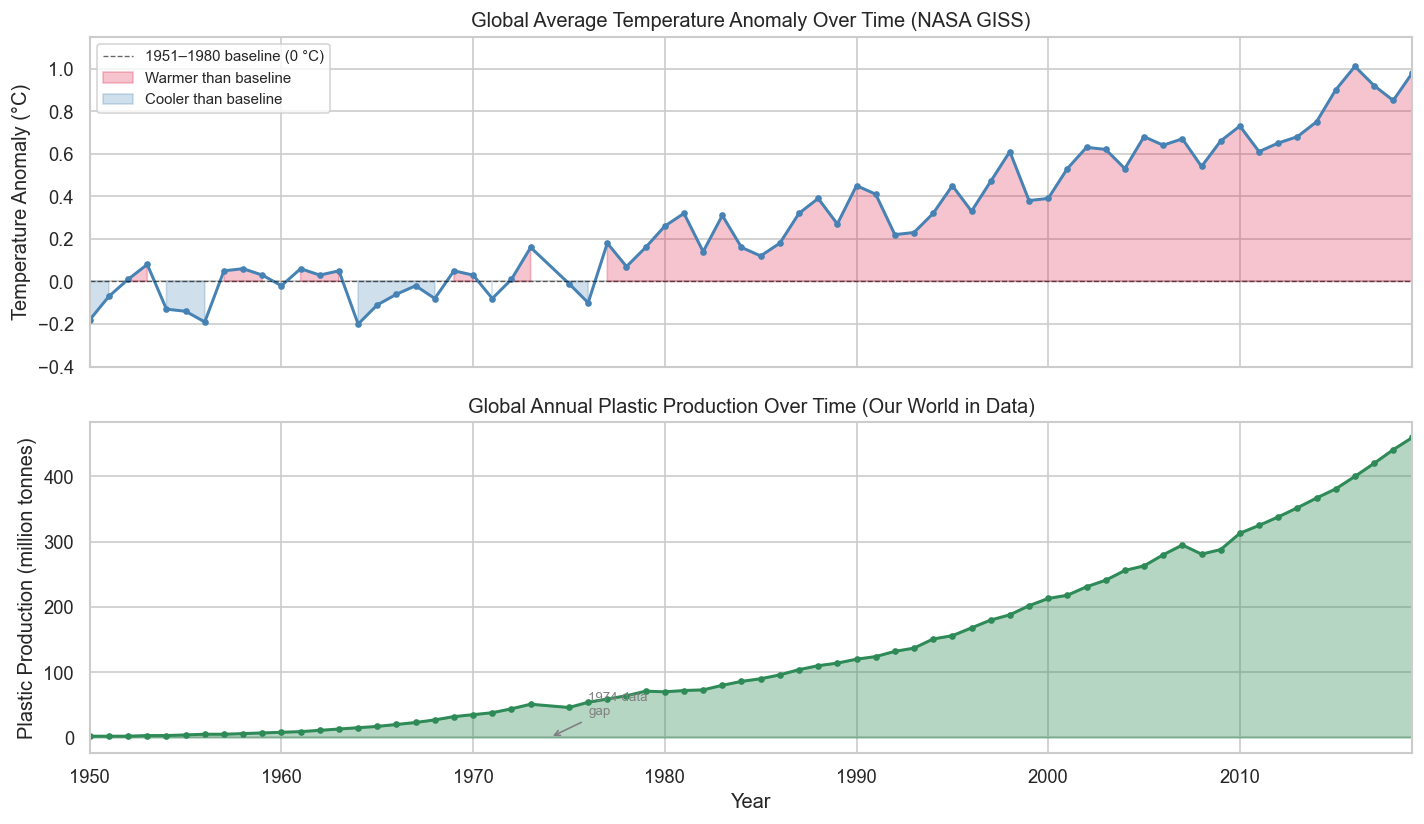

Saved: eda_idhant_timeseries.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# ── Temperature anomaly over time ────────────────────────────────────────────
ax = axes[0]
ax.plot(merged['Year'], merged['temp_anomaly_C'], color='steelblue', lw=1.8, marker='o', ms=3)
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6, label='1951–1980 baseline (0 °C)')
ax.fill_between(merged['Year'], 0, merged['temp_anomaly_C'],
                where=(merged['temp_anomaly_C'] >= 0), alpha=0.25, color='crimson', label='Warmer than baseline')
ax.fill_between(merged['Year'], 0, merged['temp_anomaly_C'],
                where=(merged['temp_anomaly_C'] < 0), alpha=0.25, color='steelblue', label='Cooler than baseline')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Global Average Temperature Anomaly Over Time (NASA GISS)')
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(-0.4, 1.15)

# ── Plastic production over time ─────────────────────────────────────────────
ax = axes[1]
ax.fill_between(merged['Year'], 0, merged['plastic_Mt'], color='seagreen', alpha=0.35)
ax.plot(merged['Year'], merged['plastic_Mt'], color='seagreen', lw=1.8, marker='o', ms=3)
# Annotate 1974 gap
ax.annotate('1974 data\ngap', xy=(1974, 0), xytext=(1976, 35),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=8, color='gray')
ax.set_ylabel('Plastic Production (million tonnes)')
ax.set_xlabel('Year')
ax.set_title('Global Annual Plastic Production Over Time (Our World in Data)')
ax.set_xlim(1950, 2019)

plt.tight_layout()
plt.savefig(RESULTS_DIR + 'eda_idhant_timeseries.png', bbox_inches='tight')
plt.show()
print('Saved: eda_idhant_timeseries.png')

**Interpretation:**

- **Temperature anomaly** (top): From 1950 through the mid-1970s, anomalies hover near or below the baseline. Starting around 1980, a clear upward trend emerges and accelerates through 2019. The year 1998 shows a notable spike (+0.61 °C), associated with a strong El Niño event. By 2016, the anomaly reaches +1.01 °C — crossing the Paris Agreement's 1 °C threshold.
- **Plastic production** (bottom): Growth is nearly monotonically increasing, with a dip in 2008 coinciding with the global financial crisis. The trajectory is roughly exponential from 1950 through the 1990s, then becomes more linear post-2000. Production grew from 2 Mt (1950) to ~460 Mt (2019).
- **Visual impression:** Both series share a persistent upward trend over the 1950–2019 window — a necessary but not sufficient condition for correlation. We must examine this more carefully in the sections below.

---
## 5. Dual-Axis Time Series: Co-Movement

Plotting both variables on the same time axis (with separate y-axes) makes it easier to visually assess co-movement and identify periods where the two trends diverge or align especially strongly.

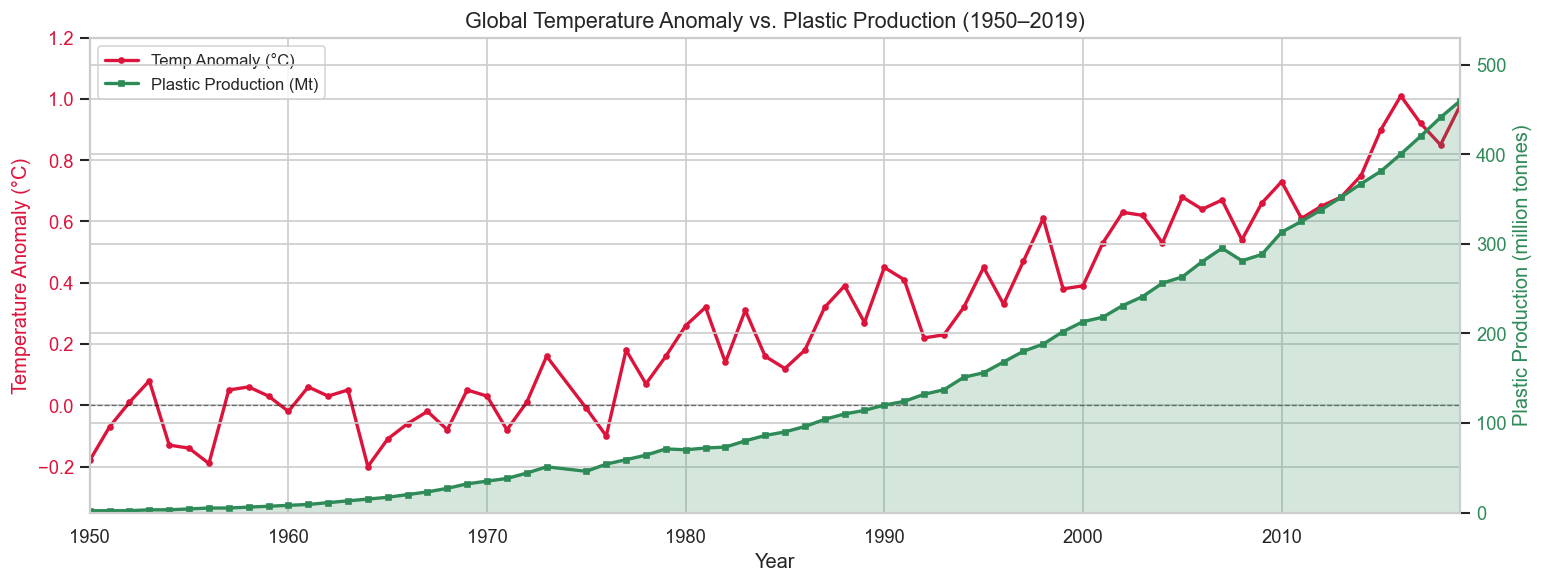

Saved: eda_idhant_dual_axis.png


In [7]:
fig, ax1 = plt.subplots(figsize=(13, 5))

color_temp    = 'crimson'
color_plastic = 'seagreen'

# Left axis: temperature anomaly
ax1.plot(merged['Year'], merged['temp_anomaly_C'], color=color_temp, lw=2, marker='o', ms=3, label='Temp Anomaly (°C)')
ax1.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax1.set_ylabel('Temperature Anomaly (°C)', color=color_temp, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_temp)
ax1.set_ylim(-0.35, 1.2)

# Right axis: plastic production
ax2 = ax1.twinx()
ax2.fill_between(merged['Year'], 0, merged['plastic_Mt'], color=color_plastic, alpha=0.2)
ax2.plot(merged['Year'], merged['plastic_Mt'], color=color_plastic, lw=2, marker='s', ms=3, label='Plastic Production (Mt)')
ax2.set_ylabel('Plastic Production (million tonnes)', color=color_plastic, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_plastic)
ax2.set_ylim(0, 530)

ax1.set_xlabel('Year', fontsize=12)
ax1.set_title('Global Temperature Anomaly vs. Plastic Production (1950–2019)', fontsize=13)
ax1.set_xlim(1950, 2019)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR + 'eda_idhant_dual_axis.png', bbox_inches='tight')
plt.show()
print('Saved: eda_idhant_dual_axis.png')

**Interpretation:**

The dual-axis plot reveals strong visual co-movement: as plastic production grows from 1950 to 2019, temperature anomalies also trend upward over the same period. Both variables appear to accelerate after roughly 1980.

However, an important caveat: **both series share a common time-based trend**. Even two completely unrelated quantities that both happen to grow over decades will show a high raw correlation. This is the classic *spurious correlation* problem in time series. Section 7 addresses this by examining the first differences (year-over-year changes), which removes the shared trend.

---
## 6. Scatter Plot & Correlation (Raw Values)

We directly plot temperature anomaly against plastic production and compute Pearson and Spearman correlation coefficients using `eda_utils.compute_correlations()` — a shared helper in `modules/eda_utils.py` that we also use in Section 7, avoiding code duplication.

[Raw] Pearson  r = 0.9525  (p = 2.66e-36)
[Raw] Spearman r = 0.9355  (p = 5.45e-32)


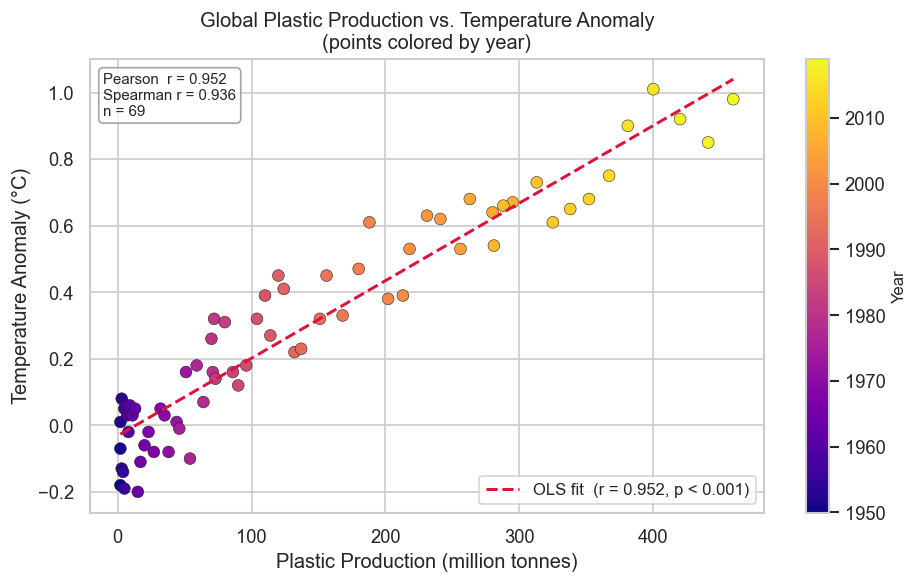

Saved: eda_idhant_scatter.png


In [8]:
# ── Compute correlations via shared module ────────────────────────────────────
raw_corr = eda_utils.compute_correlations(
    merged['plastic_Mt'], merged['temp_anomaly_C'], label='Raw'
)
pearson_r,  pearson_p  = raw_corr['pearson_r'],  raw_corr['pearson_p']
spearman_r, spearman_p = raw_corr['spearman_r'], raw_corr['spearman_p']

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    merged['plastic_Mt'], merged['temp_anomaly_C'],
    c=merged['Year'], cmap='plasma', s=50, edgecolors='k', lw=0.3, zorder=3
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year', fontsize=10)

# OLS regression line
slope, intercept, *_ = stats.linregress(merged['plastic_Mt'], merged['temp_anomaly_C'])
x_line = np.linspace(merged['plastic_Mt'].min(), merged['plastic_Mt'].max(), 200)
ax.plot(x_line, slope * x_line + intercept, color='crimson', lw=1.8, ls='--', zorder=4,
        label=f'OLS fit  (r = {pearson_r:.3f}, p < 0.001)')

ax.set_xlabel('Plastic Production (million tonnes)', fontsize=12)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=12)
ax.set_title('Global Plastic Production vs. Temperature Anomaly\n(points colored by year)', fontsize=12)
ax.legend(fontsize=10)

# Annotation box
textstr = (f'Pearson  r = {pearson_r:.3f}\n'
           f'Spearman r = {spearman_r:.3f}\n'
           f'n = {len(merged)}')
props = dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray')
ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig(RESULTS_DIR + 'eda_idhant_scatter.png', bbox_inches='tight')
plt.show()
print('Saved: eda_idhant_scatter.png')

**Interpretation:**

- Both **Pearson r = 0.953** and **Spearman r = 0.936** are very high, with p-values far below any conventional significance threshold (p ≪ 0.001). On raw values, there is an extremely strong positive association between plastic production and global temperature anomaly.
- The color gradient (dark purple = 1950s → yellow = 2010s) shows a clean chronological progression along the fitted line — early years cluster in the bottom-left (low plastic, low anomaly) and recent years in the top-right (high plastic, high anomaly). This confirms the relationship is largely driven by shared temporal trends.
- The scatter is somewhat tighter in the early decades and wider in the later decades (heteroscedasticity), consistent with greater natural variability in temperature at higher baseline levels.

> **Important caveat:** These high correlations must be interpreted with caution. Because both variables trend upward over the same time window, the raw correlation is inflated by the shared time trend. The next section examines whether a correlation exists *after removing this trend*.

---
## 7. First-Difference Analysis (Detrended Correlation)

To address the spurious correlation concern, we compute **first differences** — year-over-year changes in each variable:

$$\Delta X_t = X_t - X_{t-1}$$

First-differencing removes the shared upward trend, leaving only short-term fluctuations. If the two variables are genuinely related (not just co-trending), we would expect a positive correlation in their first differences as well.

[First-difference] Pearson  r = 0.1147  (p = 3.52e-01)
[First-difference] Spearman r = 0.1287  (p = 2.96e-01)


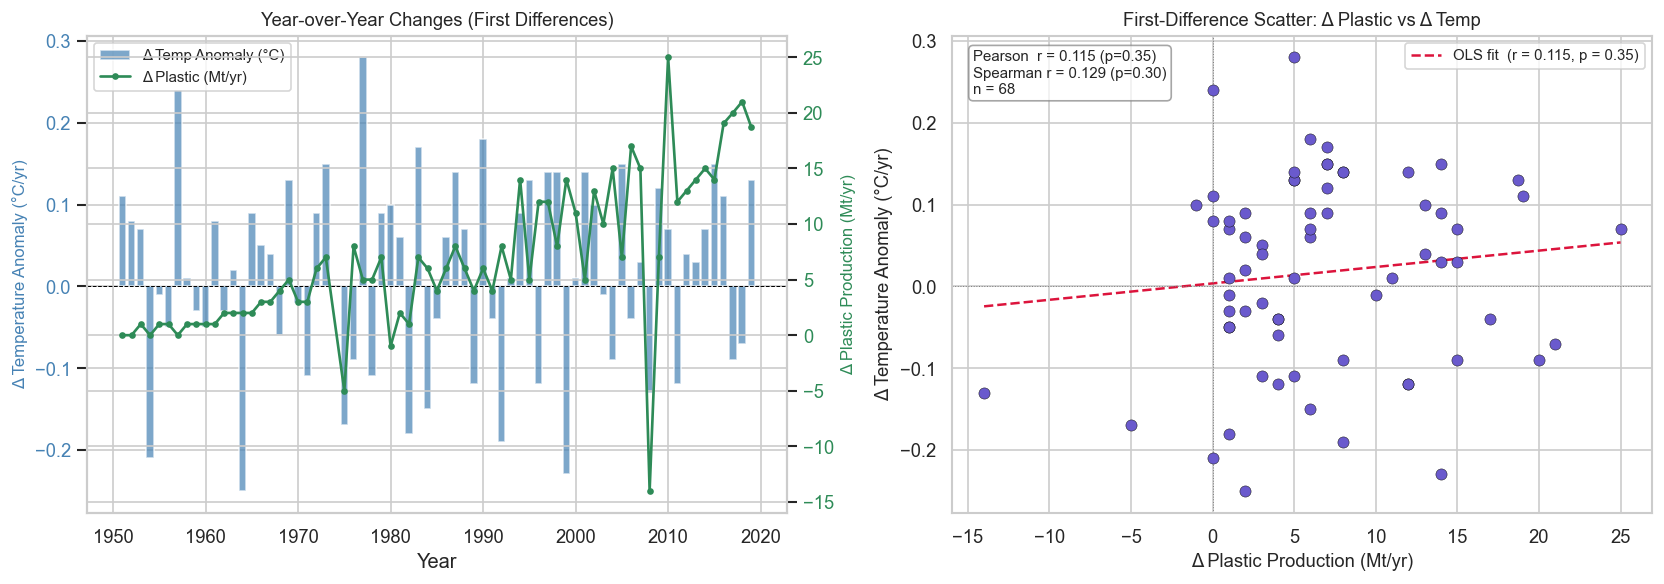

Saved: eda_idhant_firstdiff.png


In [9]:
# ── Compute first differences ─────────────────────────────────────────────────
diff = merged.copy()
diff['d_temp']    = diff['temp_anomaly_C'].diff()
diff['d_plastic'] = diff['plastic_Mt'].diff()
diff = diff.dropna(subset=['d_temp', 'd_plastic'])

# Correlations on first differences — same helper as Section 6
fd_corr = eda_utils.compute_correlations(
    diff['d_plastic'], diff['d_temp'], label='First-difference'
)
fd_pearson_r,  fd_pearson_p  = fd_corr['pearson_r'],  fd_corr['pearson_p']
fd_spearman_r, fd_spearman_p = fd_corr['spearman_r'], fd_corr['spearman_p']

# ── Plot first differences and their scatter ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: time series of first differences
ax = axes[0]
ax.bar(diff['Year'], diff['d_temp'], color='steelblue', alpha=0.7, label='Δ Temp Anomaly (°C)')
ax2_fd = ax.twinx()
ax2_fd.plot(diff['Year'], diff['d_plastic'], color='seagreen', lw=1.6, marker='o', ms=3, label='Δ Plastic (Mt/yr)')
ax2_fd.set_ylabel('Δ Plastic Production (Mt/yr)', color='seagreen', fontsize=10)
ax2_fd.tick_params(axis='y', labelcolor='seagreen')
ax.set_ylabel('Δ Temperature Anomaly (°C/yr)', color='steelblue', fontsize=10)
ax.tick_params(axis='y', labelcolor='steelblue')
ax.set_title('Year-over-Year Changes (First Differences)', fontsize=11)
ax.set_xlabel('Year')
lines_a, labs_a = ax.get_legend_handles_labels()
lines_b, labs_b = ax2_fd.get_legend_handles_labels()
ax.legend(lines_a + lines_b, labs_a + labs_b, fontsize=9, loc='upper left')
ax.axhline(0, color='black', lw=0.6, ls='--')

# Right: scatter of first differences
ax = axes[1]
ax.scatter(diff['d_plastic'], diff['d_temp'], color='slateblue', edgecolors='k', lw=0.3, s=45, zorder=3)
slope_fd, intercept_fd, *_ = stats.linregress(diff['d_plastic'], diff['d_temp'])
x_fd = np.linspace(diff['d_plastic'].min(), diff['d_plastic'].max(), 200)
ax.plot(x_fd, slope_fd * x_fd + intercept_fd, color='crimson', lw=1.5, ls='--',
        label=f'OLS fit  (r = {fd_pearson_r:.3f}, p = {fd_pearson_p:.2f})')
ax.axhline(0, color='gray', lw=0.6, ls=':')
ax.axvline(0, color='gray', lw=0.6, ls=':')
ax.set_xlabel('Δ Plastic Production (Mt/yr)', fontsize=11)
ax.set_ylabel('Δ Temperature Anomaly (°C/yr)', fontsize=11)
ax.set_title('First-Difference Scatter: Δ Plastic vs Δ Temp', fontsize=11)
textstr_fd = (f'Pearson  r = {fd_pearson_r:.3f} (p={fd_pearson_p:.2f})\n'
              f'Spearman r = {fd_spearman_r:.3f} (p={fd_spearman_p:.2f})\n'
              f'n = {len(diff)}')
props = dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray')
ax.text(0.03, 0.97, textstr_fd, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR + 'eda_idhant_firstdiff.png', bbox_inches='tight')
plt.show()
print('Saved: eda_idhant_firstdiff.png')

**Interpretation:**

After first-differencing, the correlation drops dramatically: **Pearson r = 0.115 (p = 0.35)** and **Spearman r = 0.129 (p = 0.30)**. Neither is statistically significant at any conventional threshold.

This tells us that year-to-year increases in plastic production are **not** reliably accompanied by year-to-year temperature increases. The extremely high raw correlations from Section 6 were therefore largely **spurious** — both variables happen to grow over the same decades, but they do not co-vary on a shorter timescale.

This makes physical sense: global mean temperature is driven primarily by ENSO cycles, volcanic eruptions, and solar variability on short timescales — none of which track year-to-year changes in plastic output. The connection between industrialization and climate is a long-run, cumulative phenomenon, not an annual one.

**Implication for the final analysis:** The project hypothesis (a statistically significant correlation between plastic production and temperature anomalies) holds in a long-run, trend-level sense, but robust inference will require methods that explicitly account for the shared time trend — such as cointegration testing or regression with a time control — rather than relying on raw Pearson r.

---
## 8. EDA Summary

| Analysis | Key Finding |
|---|---|
| Summary statistics | Plastic production grew >200× (2 Mt → ~460 Mt); temperature anomaly shifted from −0.18 to +1.01 °C over 1950–2019 |
| Distributions | Temp anomaly is roughly bimodal; plastic production is strongly right-skewed |
| Time series | Both variables show persistent upward trends; plastic growth is nearly monotonic; temperature shows more year-to-year variability |
| Dual-axis co-movement | Strong visual co-movement, both accelerating after ~1980 |
| Raw scatter/correlation | Pearson r = 0.953, Spearman r = 0.936 (p ≪ 0.001) — very high, but largely driven by shared time trend |
| First-difference (detrended) | Pearson r = 0.115 (p = 0.35), Spearman r = 0.129 (p = 0.30) — not significant; year-to-year co-variation is near zero |

**Implications for the final analysis:**

1. The raw correlation is very high and supports the project hypothesis directionally, but is largely trend-driven.
2. Robust inference will require detrending methods (time-series regression with trend controls, or cointegration testing) to distinguish genuine relationship from shared temporal growth.
3. The missing year 1974 (one data point) is unlikely to materially affect conclusions.
4. Both variables are **time series**, not independent samples — standard Pearson p-values underestimate uncertainty due to autocorrelation. Final analysis should account for this.